In [2]:
import pandas as pd

In [ ]:
#covert dataframe

In [20]:
df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [21]:
import numpy as np
df['Weather'] =np.where(df['Weather']=='Cloudy',0,np.where(df['Weather']=='Rain',1,2))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,Hot,High,Weak,No
1,Day 2,2,Hot,High,Strong,No
2,Day 3,0,Hot,High,Weak,Yes
3,Day 4,1,Mild,High,Weak,Yes
4,Day 5,1,Cool,Normal,Weak,Yes
5,Day 6,1,Cool,Normal,Strong,No
6,Day 7,0,Cool,Normal,Strong,Yes
7,Day 8,2,Mild,High,Weak,No
8,Day 9,2,Cool,Normal,Weak,Yes
9,Day 10,1,Mild,Normal,Weak,Yes


In [22]:
df['Temperature']=np.where(df['Temperature']=='Cool',0,
                            np.where(df['Temperature']=='Hot',1,2))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,High,Weak,No
1,Day 2,2,1,High,Strong,No
2,Day 3,0,1,High,Weak,Yes
3,Day 4,1,2,High,Weak,Yes
4,Day 5,1,0,Normal,Weak,Yes
5,Day 6,1,0,Normal,Strong,No
6,Day 7,0,0,Normal,Strong,Yes
7,Day 8,2,2,High,Weak,No
8,Day 9,2,0,Normal,Weak,Yes
9,Day 10,1,2,Normal,Weak,Yes


In [23]:
import numpy as np
df['Humidity']=np.where(df['Humidity']=='High',0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,Weak,No
1,Day 2,2,1,0,Strong,No
2,Day 3,0,1,0,Weak,Yes
3,Day 4,1,2,0,Weak,Yes
4,Day 5,1,0,1,Weak,Yes
5,Day 6,1,0,1,Strong,No
6,Day 7,0,0,1,Strong,Yes
7,Day 8,2,2,0,Weak,No
8,Day 9,2,0,1,Weak,Yes
9,Day 10,1,2,1,Weak,Yes


In [24]:
df['Wind']=np.where(df['Wind']=='strong',0,1)
                           
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,No
1,Day 2,2,1,0,1,No
2,Day 3,0,1,0,1,Yes
3,Day 4,1,2,0,1,Yes
4,Day 5,1,0,1,1,Yes
5,Day 6,1,0,1,1,No
6,Day 7,0,0,1,1,Yes
7,Day 8,2,2,0,1,No
8,Day 9,2,0,1,1,Yes
9,Day 10,1,2,1,1,Yes


In [15]:
df['Play_Sports?']=np.where(df['Play_Sports?']=='No',0,1)                    
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,0,1,0
1,2,1,0,1,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,1,0
6,0,0,1,1,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [26]:
df=pd.read_csv("Categorized_Sports_Data.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [ ]:
#converted data frame

In [30]:
df.drop("Day",axis=1,inplace=True)

In [31]:
x=df.iloc[:,:4]
y=df.iloc[:,-1]

In [32]:
x.columns

Index(['Weather', 'Temperature', 'Humidity', 'Wind'], dtype='object')

In [73]:
from sklearn.tree import DecisionTreeClassifier
dtree= DecisionTreeClassifier(criterion="entropy",max_depth=3)
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [35]:
from sklearn.tree import export_text
text_represent=export_text(dtree)
print(text_represent)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_1 <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  1.00
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , confusion_matrix
cm= confusion_matrix (y,prediction)
print(cm)

[[5 0]
 [0 9]]


In [37]:
accuracy_score(y,prediction)

1.0

In [38]:
recall_score(y,prediction)

1.0

In [39]:
precision_score(y,prediction)

1.0

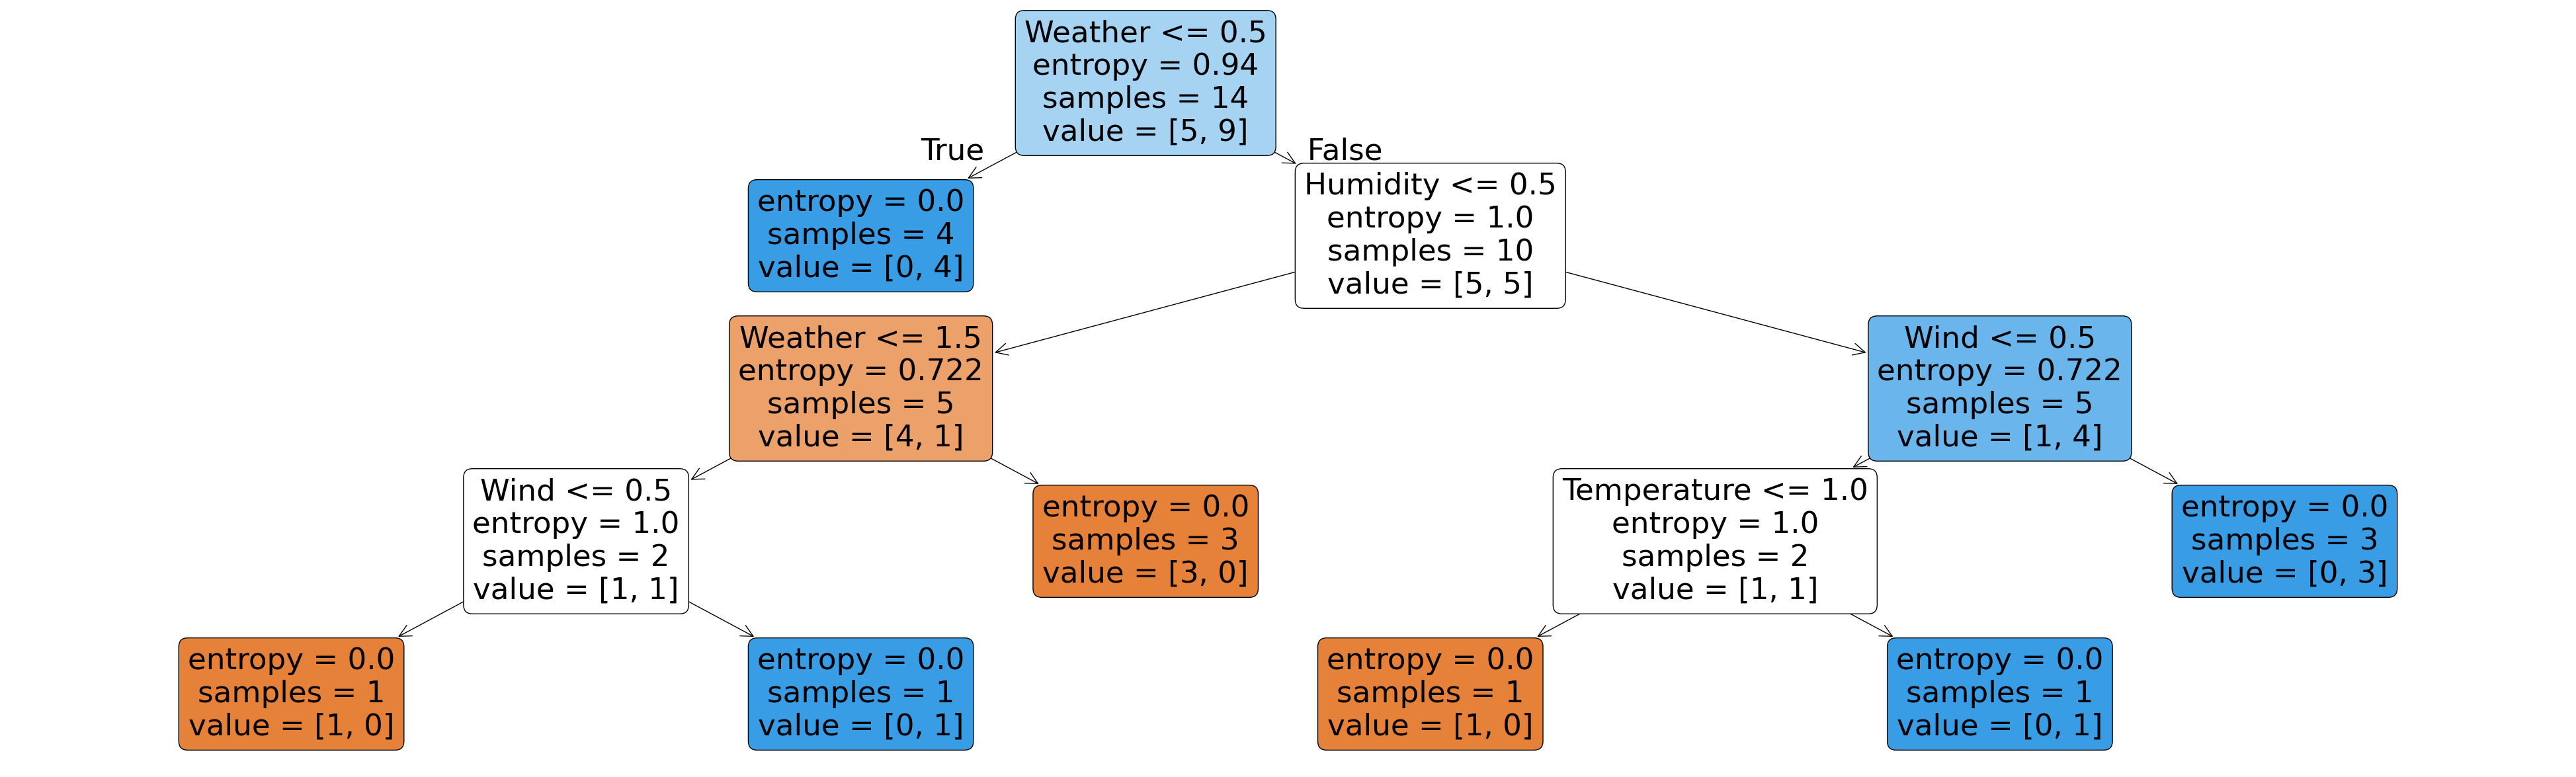

In [40]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(50,15))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [62]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [63]:
x=df[["CGPA","Communication","Apptitude","Programming Skill"]]
y=df["Job Offered"]

In [64]:
from sklearn.tree import DecisionTreeClassifier
dtree= DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x,y)
prediction=model.predict(x)
prediction

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [66]:
from sklearn.tree import export_text
text_represent=export_text(dtree)
print(text_represent)

|--- feature_2 <= 0.50
|   |--- class: 0
|--- feature_2 >  0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- class: 0
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 1



In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , confusion_matrix
cm= confusion_matrix (y,prediction)
print(cm)

[[10  0]
 [ 0  8]]


In [68]:
accuracy_score(y,prediction)

1.0

In [69]:
recall_score(y,prediction)

1.0

In [70]:
precision_score(y,prediction)

1.0

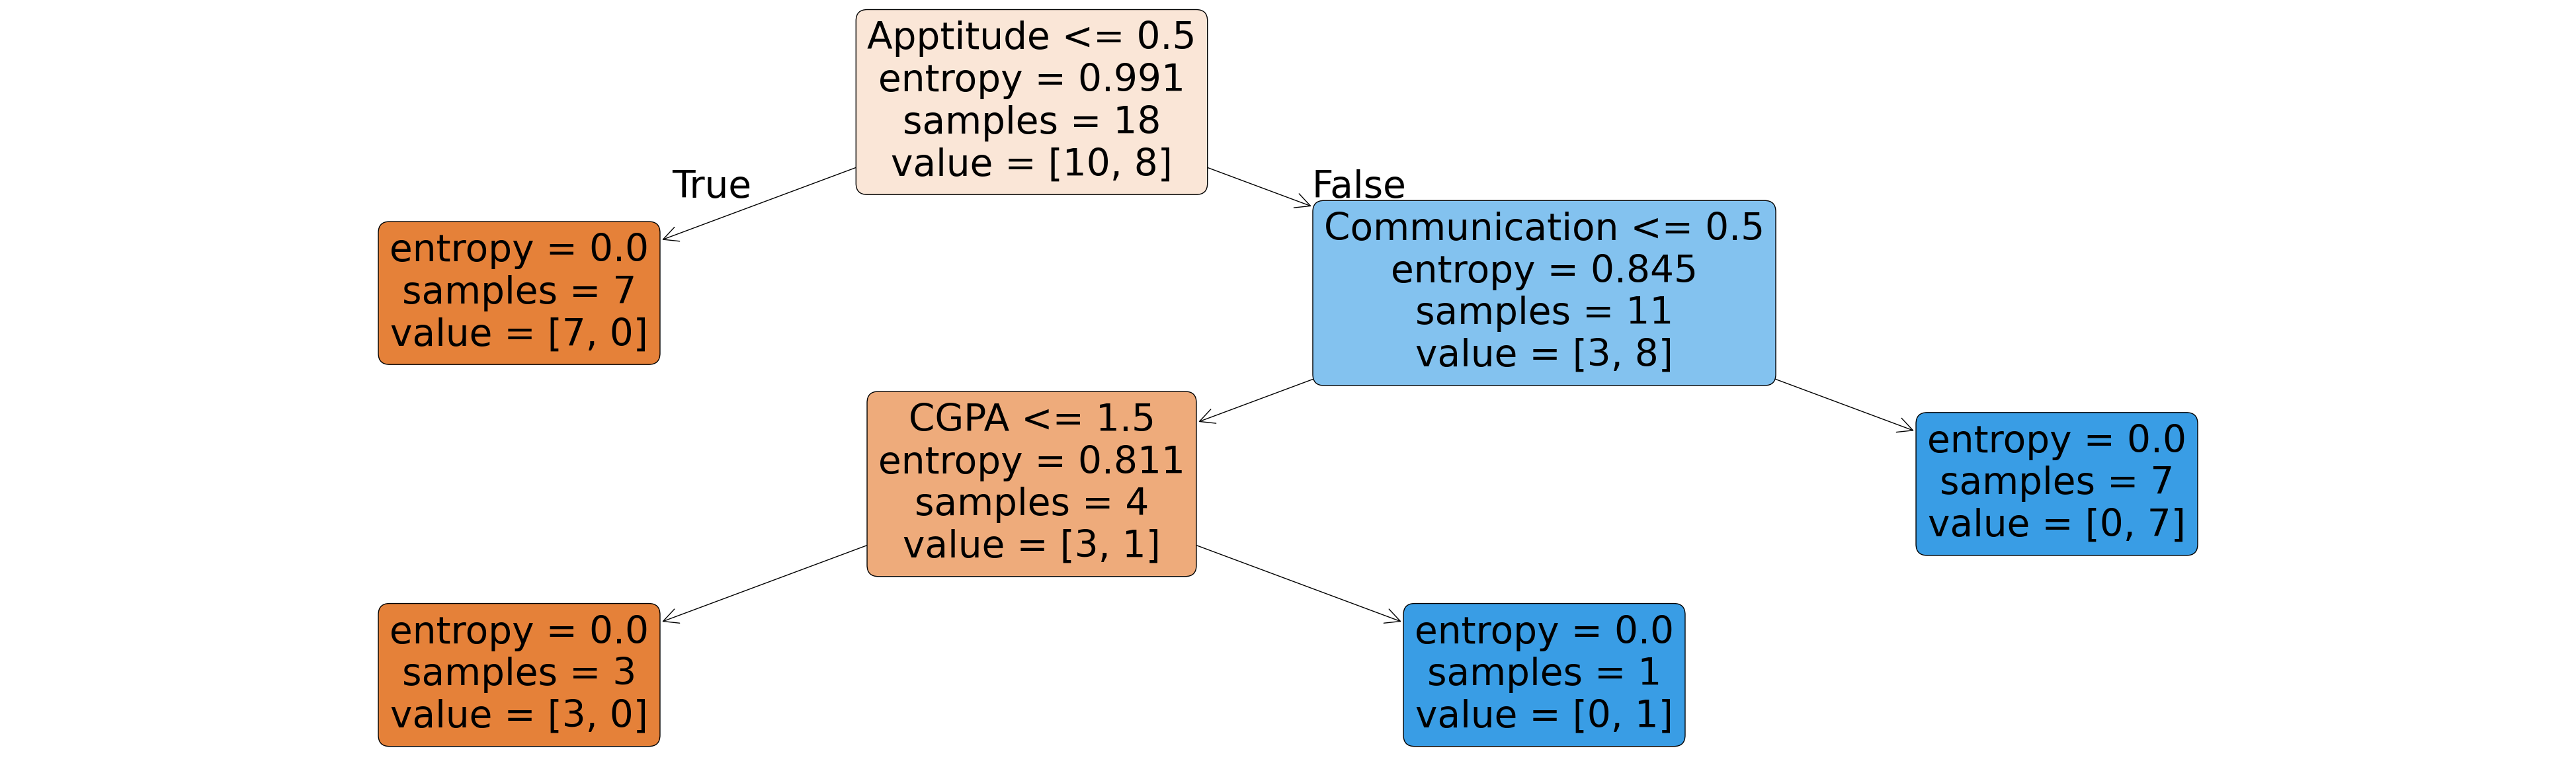

In [75]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(50,15))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [72]:
dtree.get_depth()

3

In [77]:
df=pd.read_csv("diabetes1.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [81]:
x=df.iloc[:,0:8]
y=df["Outcome"]

In [90]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1) 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [92]:
from sklearn.tree import DecisionTreeClassifier
dtree= DecisionTreeClassifier(criterion="entropy",max_depth=4)
model=dtree.fit(x,y)
prediction=model.predict(x)
prediction

array([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [87]:
from sklearn.tree import export_text
text_represent=export_text(dtree)
print(text_represent)

|--- feature_1 <= 127.50
|   |--- feature_7 <= 28.50
|   |   |--- feature_5 <= 30.95
|   |   |   |--- feature_0 <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  7.50
|   |   |   |   |--- class: 1
|   |   |--- feature_5 >  30.95
|   |   |   |--- feature_2 <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- feature_2 >  37.00
|   |   |   |   |--- class: 0
|   |--- feature_7 >  28.50
|   |   |--- feature_5 <= 26.35
|   |   |   |--- feature_5 <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- feature_5 >  9.65
|   |   |   |   |--- class: 0
|   |   |--- feature_5 >  26.35
|   |   |   |--- feature_1 <= 99.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  99.50
|   |   |   |   |--- class: 0
|--- feature_1 >  127.50
|   |--- feature_5 <= 29.95
|   |   |--- feature_1 <= 145.50
|   |   |   |--- feature_4 <= 132.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_4 >  132.50
|   |   |   |   |--- class: 0
|   |   |--- feature_1 >  145.50
|   |   |   |-

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , confusion_matrix
cm= confusion_matrix (y_test,prediction)
print(cm)

[[432  68]
 [ 96 172]]


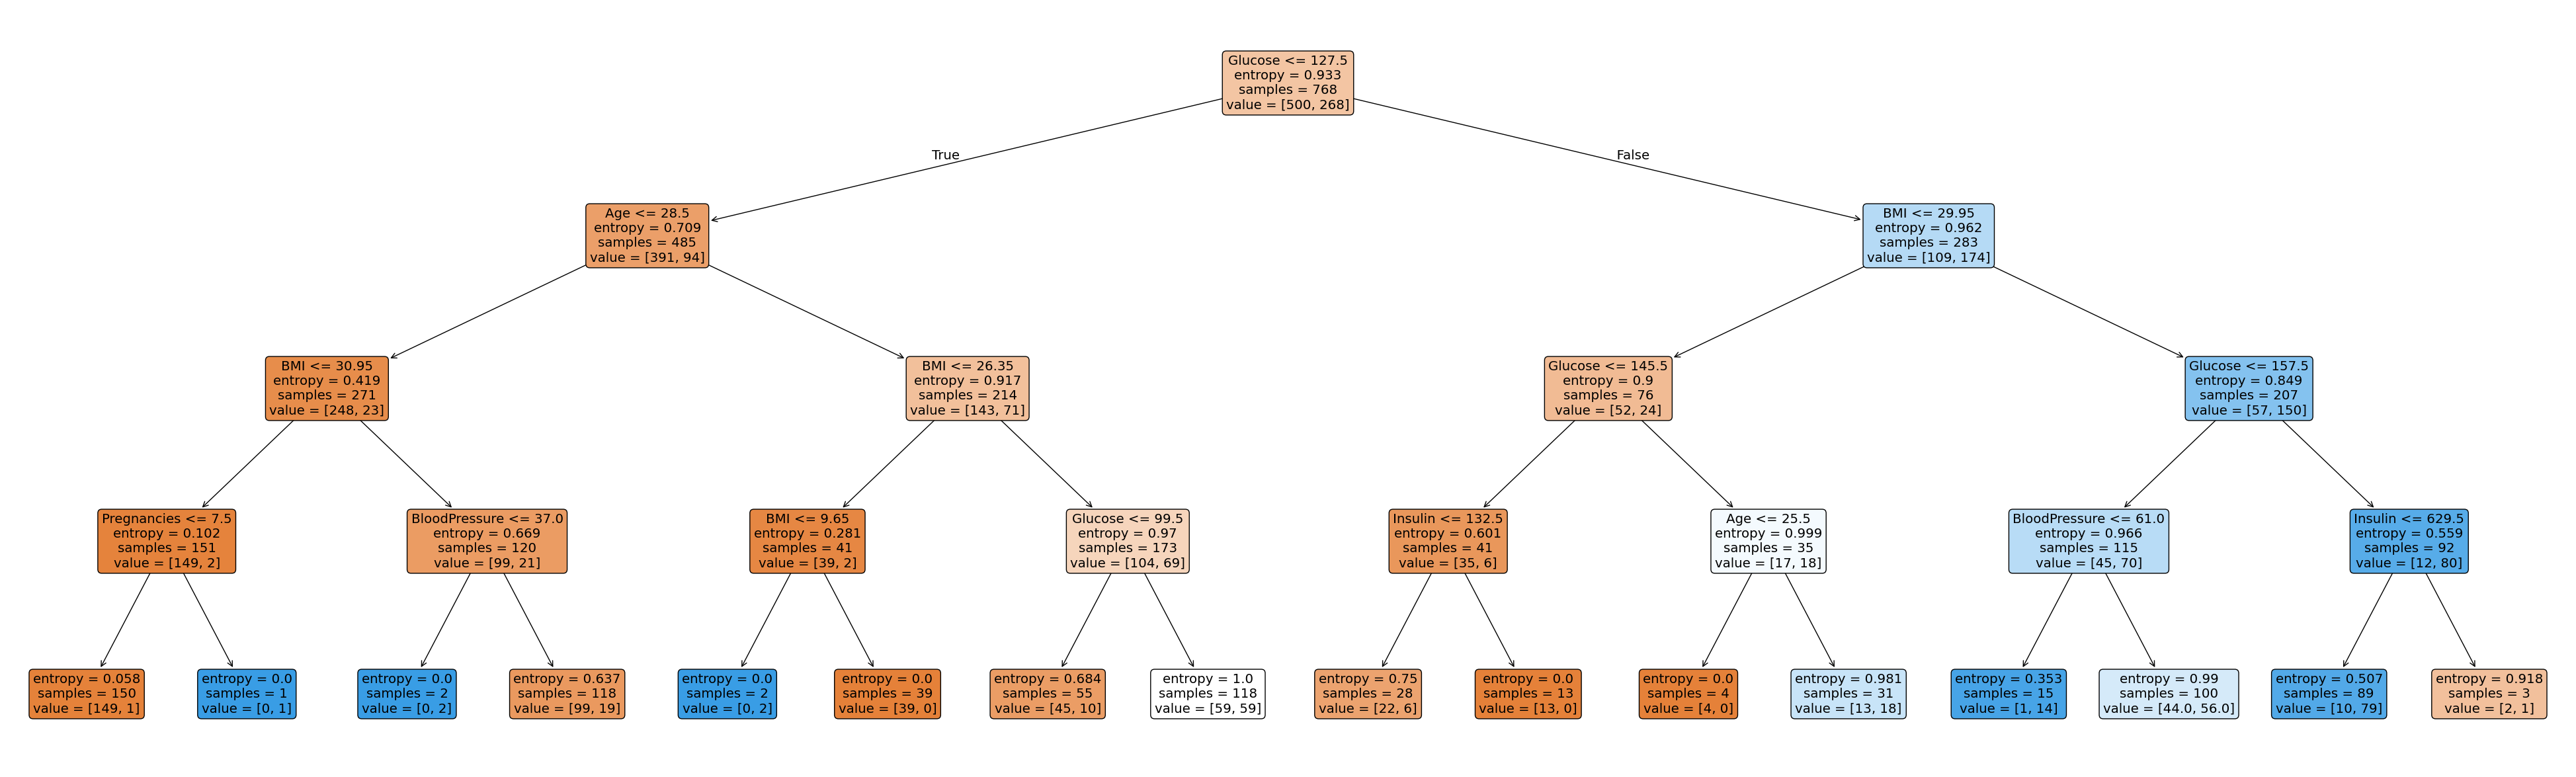

In [89]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(50,15))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [93]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1) 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [94]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [95]:
diff=pd.DataFrame({'Actual':y_test,'Predicted':prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


# Random Forest

### Bagging (Bootstrap Aggregating)
- Takes original dataset and creates random samples with replacement


In [96]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [99]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [100]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [101]:
df['Sex']=np.where(df['Sex']=='male',1,0)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [102]:
x=df[["Pclass","Sex","Age","SibSp","Parch","Fare"]]
y=df['Survived']
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [103]:
x.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [104]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1) 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [109]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(criterion='entropy'
                                     ,n_estimators=100,random_state=42)
rf_classifier.fit(x_train,y_train)
prediction=rf_classifier.predict(x_test)
print(prediction)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [110]:
from sklearn.metrics import accuracy_score, confusion_matrix
cm= confusion_matrix (y_test,prediction)
print(cm)

[[95 11]
 [31 42]]


In [112]:
print("Acuuracy Score: ",accuracy_score(y_test,prediction))


Acuuracy Score:  0.7653631284916201


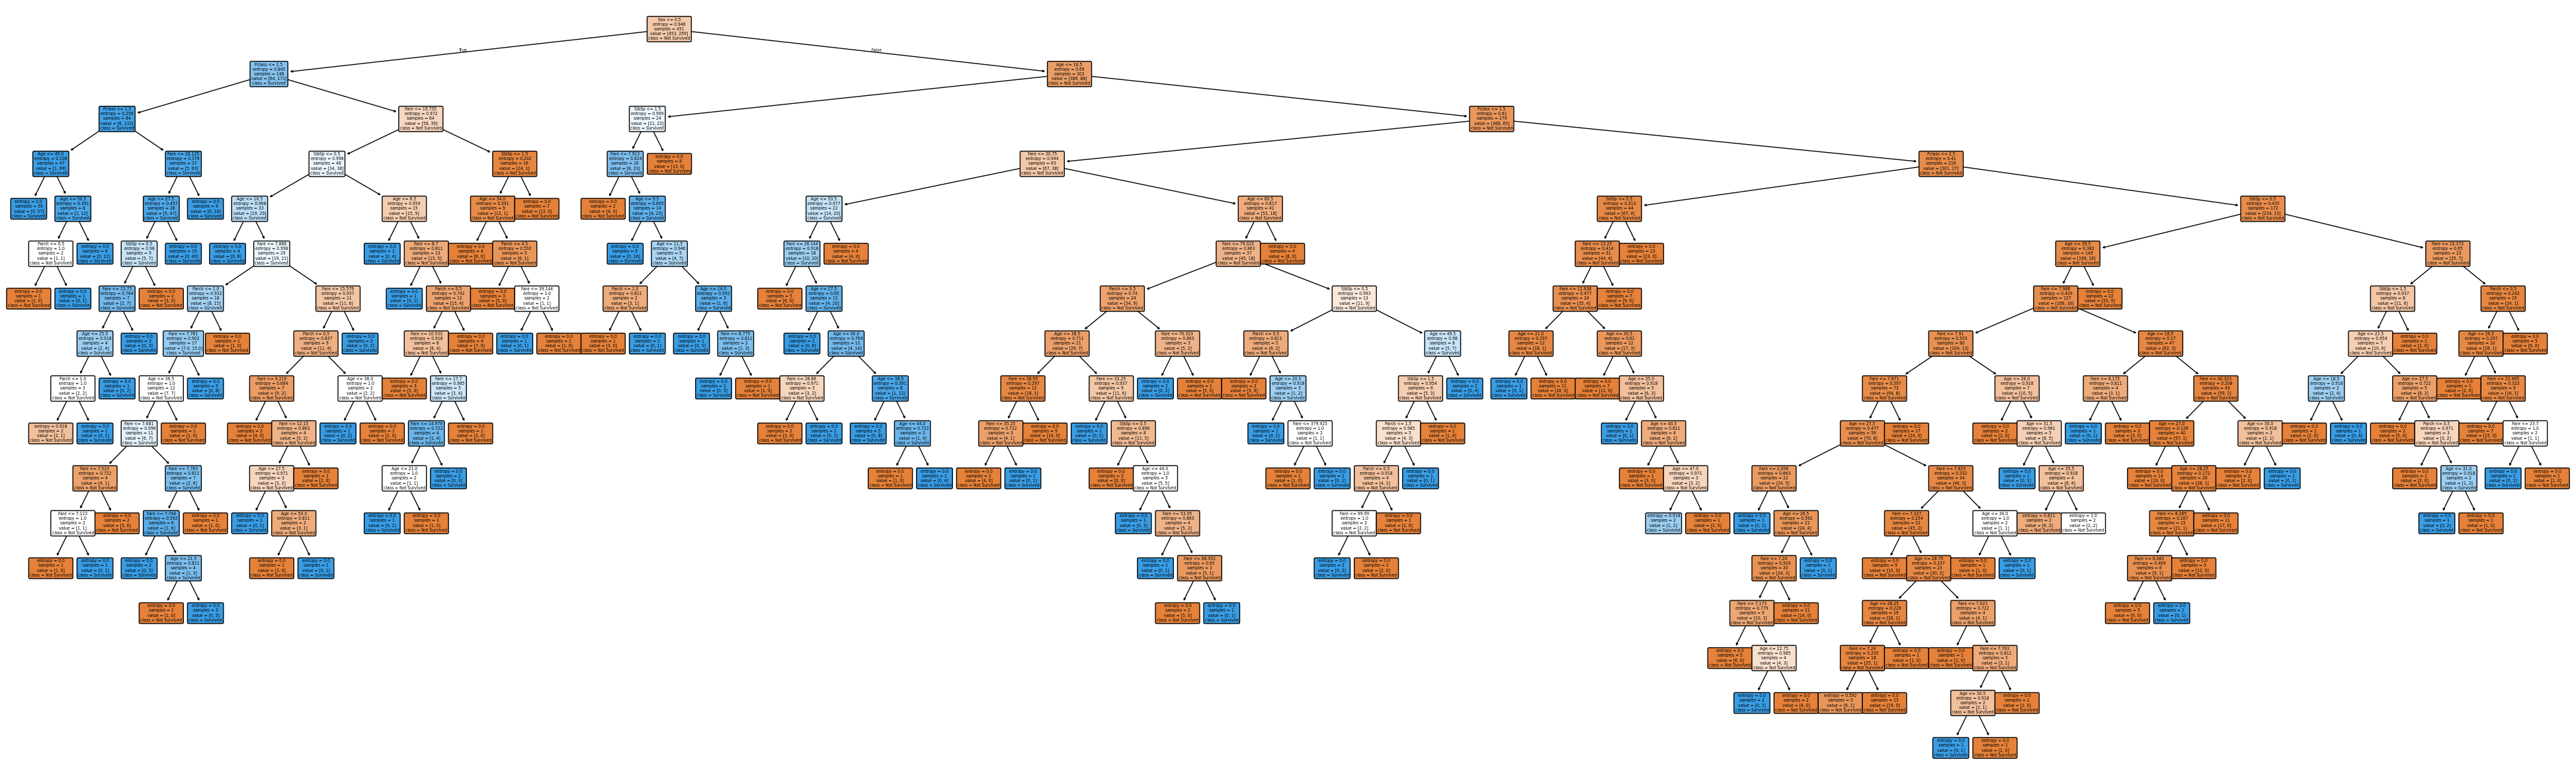

In [113]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(50,15))
choose_tree=rf_classifier.estimators_[0]
plot_tree(choose_tree,feature_names=x.columns,class_names=["Not Survived","Survived"],filled=True,rounded=True)
plt.show()